# Прогнозирование пассажиропотока авиалиний с использованием модели Холта-Винтерса

Цель проекта:
Прогнозирование количества авиапассажиров на основе исторических данных с учетом сезонности и тренда.

Используемая технология:
Модель Холта-Винтерса (тройное экспоненциальное сглаживание, ETS) — метод анализа временных рядов, который учитывает:

✔ Тренд (общая тенденция роста/падения)

✔ Сезонность (периодические колебания, например, летний спрос)

✔ Затухание тренда (снижение влияния тренда на долгосрочных прогнозах)

Почему выбрана эта модель?

Данные имеют явную сезонность (пики/спады по месяцам)

Наблюдается рост тренда (общее увеличение пассажиропотока)

Мультипликативная сезонность (амплитуда колебаний растет со временем)

Применение результатов:

Оптимизация расписания рейсов

Планирование загрузки авиакомпаний

Анализ спроса на билеты

## Коротко о данных:
📅 Период: 1949–1960 гг. (ежемесячные данные)

✈ Метрика: Количество пассажиров (в тыс.)

📈 Особенности: Рост + сезонные колебания (летний/зимний спрос)

In [2]:
# Установка необходимых библиотек (раскомментируйте при первом запуске)
# !pip install statsmodels pandas numpy matplotlib

# Импорт библиотек
import pandas as pd  # Для работы с табличными данными (DataFrame)
import numpy as np  # Для математических операций и работы с массивами
import matplotlib.pyplot as plt  # Для визуализации данных
from statsmodels.tsa.api import ExponentialSmoothing  # Для прогнозирования временных рядов
# - Методы экспоненциального сглаживания
# - Модель Холта-Винтерса
# - Прогнозирование с учетом тренда и сезонности


# Настройка отображения графиков
plt.style.use('ggplot')  # Применение стиля 'ggplot' для графиков
# - Стиль оформления как в R-пакете ggplot2
# - Приятные цветовые схемы
# - Профессиональный вид графиков

%matplotlib inline  
# Магическая команда Jupyter Notebook
# - Отображение графиков прямо в ноутбуке
# - Не требует plt.show() после каждого графика
# - Позволяет интерактивно работать с визуализациями

In [3]:
# 1. Загрузка и проверка данных
# --------------------------------------------------
# Загрузка данных из CSV-файла
try:
    flights = pd.read_csv(r'C:\Users\Admin\Documents\Flights.csv')
    print("Данные успешно загружены:")
    print(flights.head())
    print("\nПоследние записи:")
    print(flights.tail())
except FileNotFoundError:
    print("Ошибка: Файл не найден. Проверьте путь к файлу.")
    exit()

Данные успешно загружены:
     Date  flights
0  Jan-49      112
1  Feb-49      118
2  Mar-49      132
3  Apr-49      129
4  May-49      121

Последние записи:
       Date  flights
139  Aug-60      606
140  Sep-60      508
141  Oct-60      461
142  Nov-60      390
143  Dec-60      432


In [4]:
# 2. Подготовка данных
# --------------------------------------------------
# Выделение временного ряда (количество пассажиров)
passengers = flights['flights']  # Используем прямое обращение по имени столбца

# Проверка данных на пропуски и дубликаты
print("\nПроверка качества данных:")
print(f"Пропущенные значения: {passengers.isnull().sum()}")

# Убедимся, что данные чистые
assert passengers.isnull().sum() == 0, "Обнаружены пропущенные значения!"

# Вывод информации о данных
print("\nХарактеристики временного ряда:")
print(passengers.describe())


Проверка качества данных:
Пропущенные значения: 0

Характеристики временного ряда:
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: flights, dtype: float64


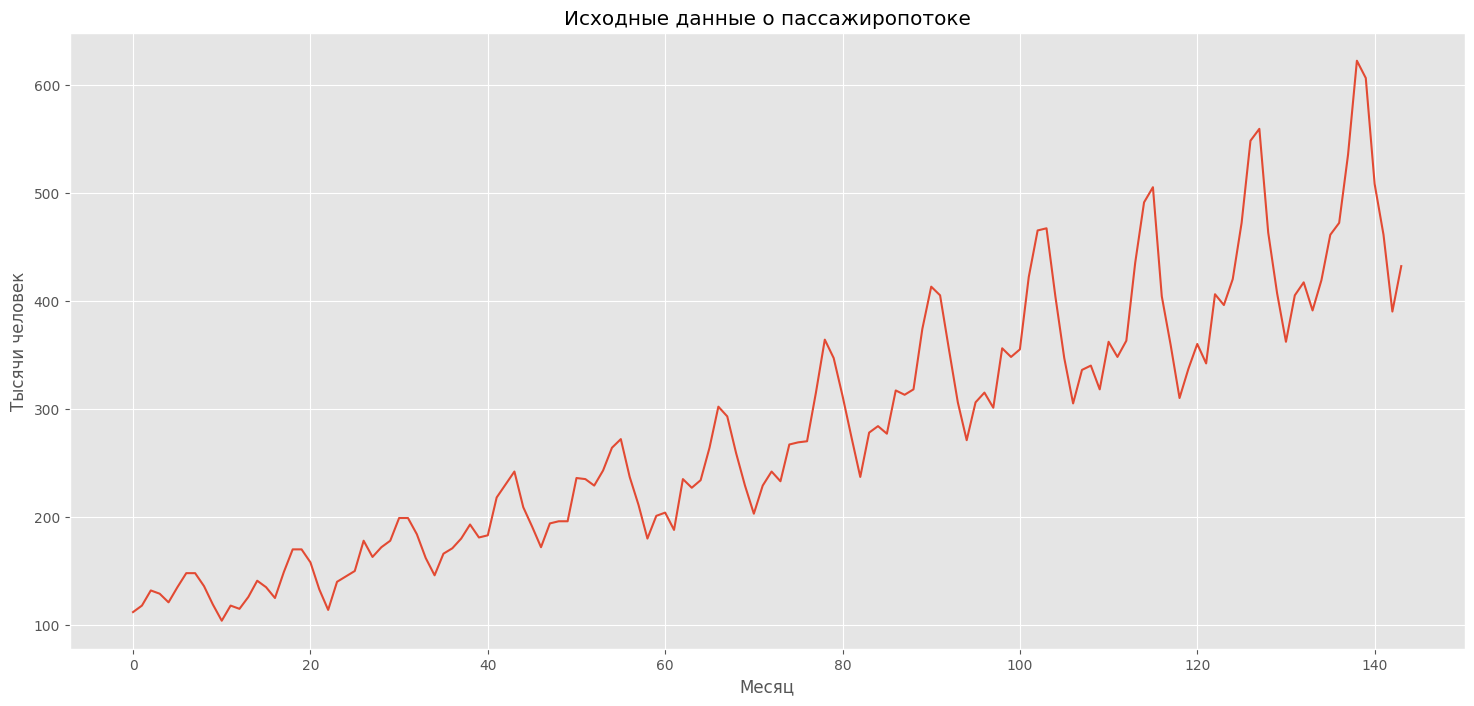

In [5]:
# 3. Визуализация исходных данных
# --------------------------------------------------
# Создаем график размером 18x8 дюймов
plt.figure(figsize=(18, 8))

# Строим линейный график временного ряда с заголовком
passengers.plot(title='Исходные данные о пассажиропотоке')

# Подписываем оси:
plt.xlabel('Месяц')  # Ось X - временная шкала (месяцы)
plt.ylabel('Тысячи человек')  # Ось Y - количество пассажиров

# Добавляем сетку для лучшей читаемости
plt.grid(True)

In [6]:
# 4. Построение модели прогнозирования
# --------------------------------------------------
# Параметры модели временного ряда

# HORIZON - количество шагов (периодов) для прогнозирования вперед
# 12 означает прогноз на 1 год вперед (месячные данные)
HORIZON = 12  # Горизонт прогнозирования (12 месяцев)

# SEASON_PERIOD - длина сезонного цикла в единицах времени
# Для месячных данных с годовой сезонностью устанавливаем 12
SEASON_PERIOD = 12  # Сезонный цикл (12 месяцев в году)

# SEASON_TYPE - тип сезонной компоненты:
# 'multiplicative' - мультипликативная (колебания растут/падают с трендом)
# 'additive' - аддитивная (постоянная амплитуда колебаний)
# Выбрана мультипликативная, так как амплитуда сезонных колебаний пассажиропотока 
# обычно растет вместе с общим ростом тренда
SEASON_TYPE = 'multiplicative'  # Тип сезонной компоненты

# Создание и обучение модели Холта-Винтерса
model = ExponentialSmoothing(
    passengers,                # Исходный временной ряд
    seasonal_periods=SEASON_PERIOD,  # Длина сезонного цикла
    trend='additive',          # Тип тренда: аддитивный (линейный)
    seasonal=SEASON_TYPE,      # Тип сезонности (выше определен как multiplicative)
    damped_trend=True          # Использовать затухающий тренд (damping уменьшает 
                             # влияние тренда на долгосрочных горизонтах прогноза)
).fit()                       # Обучение модели на исторических данных

# Генерация прогноза
# Прогнозируем:
# - с начала временного ряда (start=0)
# - до конца исторических данных + горизонт прогнозирования
# len(passengers) - длина исторических данных
# HORIZON - горизонт прогнозирования
# -1 потому что индексация начинается с 0
forecast = model.predict(
    start=0,                      # Начало прогноза (с первого наблюдения)
    end=len(passengers)+HORIZON-1 # Конец прогноза (история + горизонт)
)

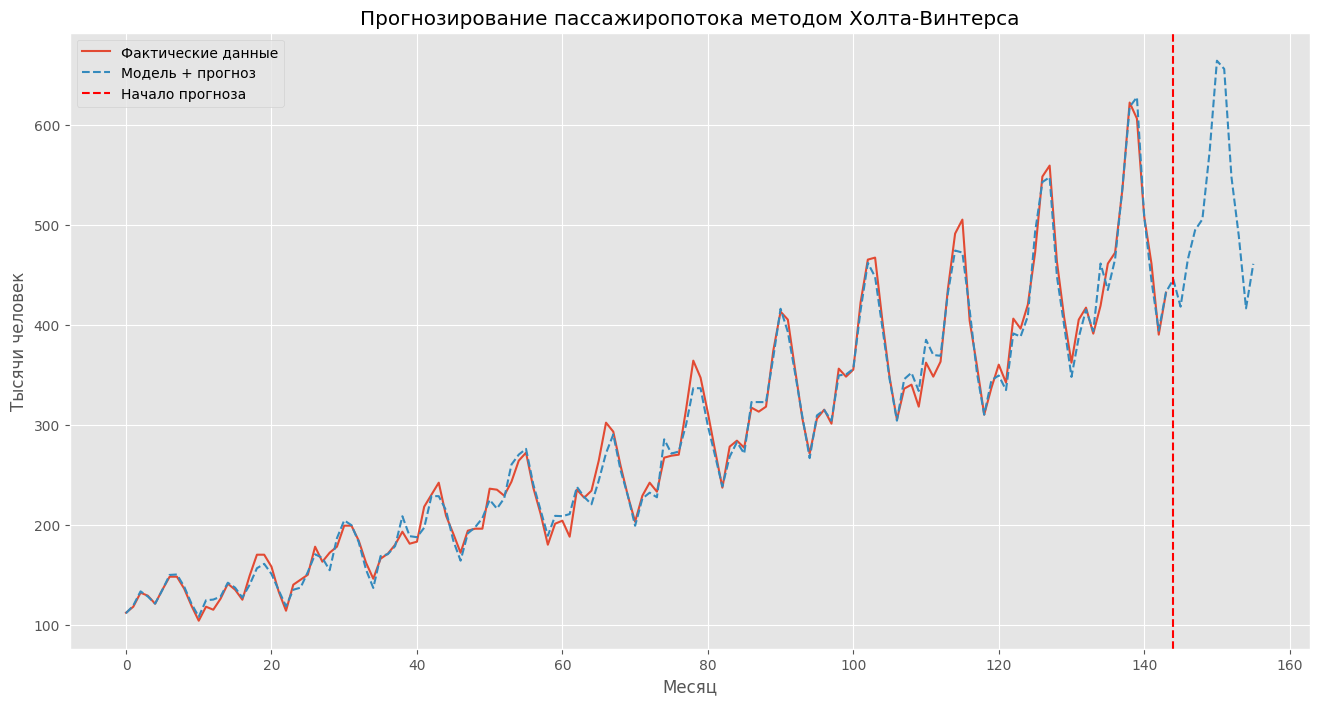

In [7]:
# 5. Визуализация результатов
# --------------------------------------------------
plt.figure(figsize=(16, 8))
plt.plot(passengers, label='Фактические данные')
plt.plot(forecast, label='Модель + прогноз', linestyle='--')
plt.axvline(x=len(passengers), color='r', linestyle='--', label='Начало прогноза')
plt.legend(loc='best')
plt.title('Прогнозирование пассажиропотока методом Холта-Винтерса')
plt.xlabel('Месяц')
plt.ylabel('Тысячи человек')
plt.grid(True)
plt.show()


In [8]:
# 6. Вывод прогноза
# --------------------------------------------------
print("\nПрогноз на следующие 12 месяцев:")
print(forecast[-HORIZON:].to_frame(name='Прогноз'))


Прогноз на следующие 12 месяцев:
        Прогноз
144  445.189893
145  417.964114
146  465.207179
147  494.494796
148  505.318607
149  573.376035
150  663.834023
151  655.625614
152  547.492808
153  489.098215
154  416.269238
155  460.777421


# Вывод

Этот проект демонстрирует прогнозирование пассажиропотока авиакомпаний с помощью модели Холта-Винтерса. Исторические данные содержат выраженную сезонность (например, летние пики спроса), поэтому выбрана мультипликативная модель. Результат — прогноз на 12 месяцев вперед, который помогает в планировании рейсов и управлении спросом.